# DGNet — SHREC16_MPS_aug
## Prétraitement, entraînement et évaluation

Pipeline complet pour l'architecture DGNet sur le dataset SHREC16 Original :
téléchargement, prétraitement, adaptation à la classification, entraînement et
évaluation. Réutilise l'environnement Python 3.10 + Jittor + les correctifs cuDNN
déjà validés sur ModelNet10.

## Étapes

1. Clonage du projet depuis GitHub (avec le sous-module DGNet officiel)
2. Validation du projet
3. Environnement Python isolé pour Jittor (venv Python 3.10 + CUDA/cuDNN)
4. Connexion du dataset SHREC16 (30 classes, 480 train / 120 test, maillages .obj déjà simplifiés à 500 faces)
5. Audit et pilote (pyramide DGNet à 6 niveaux, testée sur les 30 classes)
6. Prétraitement complet des 600 maillages
7. Dataset et modèle de classification (adaptation générique, réutilisée depuis ModelNet10)
8. Entraînement complet (120 epochs)
9. Métriques calculatoires (paramètres, temps d'inférence, mémoire GPU)
10. Courbes d'apprentissage et matrice de confusion
11. Rapport final

In [7]:
import os
from pathlib import Path

base_path = Path("/kaggle/input")
DATASET_ROOT = None

# 1. Recherche insensible à la casse dans l'arborescence /kaggle/input/
for root, dirs, files in os.walk(base_path):
    if "shrec16_mps_aug" in root.lower():
        DATASET_ROOT = Path(root)
        break

# 2. Validation et affichage
if DATASET_ROOT and DATASET_ROOT.exists():
    print(f"✅ Chemin racine trouvé : {DATASET_ROOT}\n")
    print("Contenu du dataset :")
    for item in sorted(DATASET_ROOT.iterdir()):
        kind = "📁 Dossier" if item.is_dir() else "📄 Fichier"
        print(f"  - {kind}: {item.name}")
else:
    print("❌ Non trouvé. Dossiers disponibles sous /kaggle/input/datasets :")
    datasets_dir = base_path / "datasets"
    if datasets_dir.exists():
        for p in datasets_dir.rglob("*"):
            if p.is_dir():
                print(f"  📁 {p}")

❌ Non trouvé. Dossiers disponibles sous /kaggle/input/datasets :
  📁 /kaggle/input/datasets/bilalkhallabi
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/snake
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/shark
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/horse
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/bird2
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/dinosaur
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/man
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/ants
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/two_balls
  📁 /kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug/santa
  📁 /kaggle/input/datasets/bilalkhallab

In [8]:
from pathlib import Path

WORKING_ROOT = Path("/kaggle/working")
PROJECT_NAME = "3d-mesh-augmentation-study"
PROJECT_ROOT = WORKING_ROOT / PROJECT_NAME

GITHUB_URL = "https://github.com/Bilal51002/3d-mesh-augmentation-study.git"
GITHUB_BRANCH = "feat/dgnet-modelnet10-preprocessing"

PYRAMID_LEVELS = 6

print("Project root :", PROJECT_ROOT)

Project root : /kaggle/working/3d-mesh-augmentation-study


## 1. Clonage du projet depuis GitHub

In [9]:
import os
import shutil
import subprocess

# Se replacer dans /kaggle/working AVANT toute suppression, pour ne jamais
# supprimer le repertoire dans lequel le kernel est physiquement positionne
# (sinon subprocess.run echoue avec "Unable to read current working directory").
os.chdir(WORKING_ROOT)

if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)

subprocess.run(
    [
        "git", "clone", "--recurse-submodules",
        "--branch", GITHUB_BRANCH,
        GITHUB_URL, str(PROJECT_ROOT),
    ],
    cwd=str(WORKING_ROOT),
    check=True,
)

print("✅ Projet cloné :", PROJECT_ROOT)


Cloning into '/kaggle/working/3d-mesh-augmentation-study'...
Submodule 'models/dgnet' (https://github.com/li-xl/DGNet.git) registered for path 'models/dgnet'
Cloning into '/kaggle/working/3d-mesh-augmentation-study/models/dgnet'...


Submodule path 'models/dgnet': checked out '70abf402b58f7d44f0765c0436bfb03b53af4a5d'
✅ Projet cloné : /kaggle/working/3d-mesh-augmentation-study


In [10]:
%cd /kaggle/working/3d-mesh-augmentation-study


/kaggle/working/3d-mesh-augmentation-study


In [11]:
!git branch --show-current
!git log -1 --oneline
!git submodule status


feat/dgnet-modelnet10-preprocessing
cf3dc4f (HEAD -> feat/dgnet-modelnet10-preprocessing, origin/feat/dgnet-modelnet10-preprocessing) Kaggle Notebook | 01-dgnet-modelnet10-setup-preprocessing-fusionne | Version 2
 70abf402b58f7d44f0765c0436bfb03b53af4a5d models/dgnet (heads/master)


## 2. Validation du projet

In [12]:
required_files = [
    PROJECT_ROOT / "adapters/dgnet/face_pool_compat.py",
    PROJECT_ROOT / "models/dgnet/jmesh/layers/face_pool.py",
]

missing_files = [p for p in required_files if not p.is_file()]

for path in required_files:
    status = "OK" if path.is_file() else "MANQUANT"
    print(f"{status:8} {path.relative_to(PROJECT_ROOT)}")

if missing_files:
    raise FileNotFoundError(f"Fichiers manquants : {missing_files}")

print("\n✅ Le code DGNet est complet.")

OK       adapters/dgnet/face_pool_compat.py
OK       models/dgnet/jmesh/layers/face_pool.py

✅ Le code DGNet est complet.


## 3. Environnement Python isolé pour Jittor

Jittor est installé **uniquement** dans ce venv, jamais dans le noyau principal Kaggle,
pour éviter le conflit NumPy 2.x (noyau principal) / NumPy 1.26.4 (Jittor).

### Nettoyage (a executer avant chaque reconstruction du venv)


In [13]:
import shutil
from pathlib import Path

shutil.rmtree(WORKING_ROOT / "dgnet-jittor-env", ignore_errors=True)
shutil.rmtree(Path("/root/.cache/jittor"), ignore_errors=True)
print("Nettoyage terminé.")


Nettoyage terminé.


In [14]:
import sys

VENV_ROOT = WORKING_ROOT / "dgnet-jittor-env"
VENV_PYTHON = VENV_ROOT / "bin" / "python"
READY_MARKER = VENV_ROOT / ".dgnet_environment_ready"

REQUIRED_PACKAGES = [
    "numpy==1.26.4",
    "trimesh==4.12.2",
    "fast-simplification==0.1.13",
    "jittor==1.3.11.0",
    "tensorboardX==2.6.4",
    "plyfile",
    "pyyaml",
    "tqdm",
    "scipy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "psutil",
    "networkx",
    "open3d",
    "wrapt",
]

os.chdir(WORKING_ROOT)

# Jittor 1.3.11.0 crashes on Python >= 3.11 (confirmed in its source code:
# py_var_tracer.cc checks PY_MINOR_VERSION>=11 and aborts). Use Python 3.10
# for the isolated venv instead of the main kernel's Python 3.12.
python310_path = shutil.which("python3.10")
if python310_path is None:
    print("Python 3.10 introuvable, installation via apt...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "python3.10", "python3.10-venv", "python3.10-distutils", "python3.10-dev"],
        check=True,
    )
    python310_path = shutil.which("python3.10")

if python310_path is None:
    raise RuntimeError("Impossible d'installer Python 3.10.")

print("Python 3.10 trouve :", python310_path)

environment_ready = VENV_PYTHON.is_file() and READY_MARKER.is_file()

if not environment_ready:
    if VENV_ROOT.exists():
        shutil.rmtree(VENV_ROOT)

    print("1. Installation de virtualenv...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "virtualenv"],
        cwd=WORKING_ROOT, check=True,
    )

    print("2. Création de l'environnement isolé (Python 3.10)...")
    subprocess.run(
        [sys.executable, "-m", "virtualenv", "--clear", "--python", python310_path, str(VENV_ROOT)],
        cwd=WORKING_ROOT, check=True,
    )

    if not VENV_PYTHON.is_file():
        raise FileNotFoundError(f"Python isolé introuvable : {VENV_PYTHON}")

    print("3. Installation des dépendances DGNet...")
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir",
         "--upgrade", "pip", "setuptools", "wheel"],
        cwd=WORKING_ROOT, check=True,
    )
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir", *REQUIRED_PACKAGES],
        cwd=WORKING_ROOT, check=True,
    )

    READY_MARKER.write_text("DGNet environment ready.\n", encoding="utf-8")
else:
    print("L'environnement isolé existe déjà. Installation ignorée.")

if not VENV_PYTHON.is_file():
    raise FileNotFoundError(f"Interpréteur introuvable : {VENV_PYTHON}")

print("\n✅ Environnement isolé prêt (Python 3.10)")
print("Python :", VENV_PYTHON)

Python 3.10 trouve : /usr/bin/python3.10
1. Installation de virtualenv...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 27.2 MB/s eta 0:00:00
2. Création de l'environnement isolé (Python 3.10)...
created virtual environment CPython3.10.12.final.0-64-x86_64 in 939ms
  creator CPython3Posix(dest=/kaggle/working/dgnet-jittor-env, clear=True, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.2.1, setuptools==84.0.0
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator
3. Installation des dépendances DGNet...

✅ Environnement isolé prêt (Python 3.10)
Python : /kaggle/working/dgnet-jittor-env/bin/python


In [15]:
completed = subprocess.run(
    [str(VENV_PYTHON), "-c", "import site; print(site.getsitepackages()[0])"],
    capture_output=True, text=True, check=True,
)
VENV_SITE_PACKAGES = completed.stdout.strip()

VENV_ENV = os.environ.copy()
VENV_ENV["PYTHONPATH"] = VENV_SITE_PACKAGES
VENV_ENV.pop("PYTHONSTARTUP", None)

# FIX: utiliser le nvcc DEJA installé sur le système Kaggle, pour que Jittor
# n'essaie jamais de télécharger sa propre copie CUDA (serveur cg.cs.tsinghua.edu.cn cassé).
# IMPORTANT: verifiez le vrai chemin sur CETTE session via
# find / -iname nvcc -type f 2>/dev/null -- remplacez ci-dessous si different.
VENV_ENV["nvcc_path"] = "/usr/local/cuda/bin/nvcc"

# FIX: éviter les téléchargements MKL/oneDNN et cutlass (même cause réseau que CUDA).
VENV_ENV["use_mkl"] = "0"
VENV_ENV["use_cutlass"] = "0"


def run_in_venv(args, **kwargs):
    """Lance VENV_PYTHON avec -S (ignore site/sitecustomize) et un
    PYTHONPATH explicite vers le site-packages du venv, pour eviter que
    le sitecustomize.py bruyant de Kaggle ne corrompe le cache Jittor."""
    full_args = [str(VENV_PYTHON), "-S"] + list(args)
    kwargs.setdefault("env", VENV_ENV)
    kwargs.setdefault("cwd", WORKING_ROOT)
    return subprocess.run(full_args, **kwargs)


In [16]:
import importlib
import platform

modules_to_check = {
    "NumPy": "numpy", "SciPy": "scipy", "Pandas": "pandas",
    "Scikit-learn": "sklearn", "Trimesh": "trimesh",
    "TensorBoardX": "tensorboardX", "Jittor": "jittor",
    "Plyfile": "plyfile", "PyYAML": "yaml", "TQDM": "tqdm",
}

print("Environnement Python (noyau principal)")
print("Python   :", sys.version)
print("Platform :", platform.platform())
print()
for display_name, import_name in modules_to_check.items():
    try:
        module = importlib.import_module(import_name)
        version = getattr(module, "__version__", "version non exposée")
        print(f"{display_name:<16} ✅ {version}")
    except Exception as error:
        print(f"{display_name:<16} ❌ {type(error).__name__}: {error}")


Environnement Python (noyau principal)
Python   : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform : Linux-6.12.90+-x86_64-with-glibc2.35

NumPy            ✅ 2.0.2
SciPy            ✅ 1.16.3
Pandas           ✅ 2.3.3
Scikit-learn     ✅ 1.6.1
Trimesh          ❌ ModuleNotFoundError: No module named 'trimesh'
TensorBoardX     ❌ ModuleNotFoundError: No module named 'tensorboardX'
Jittor           ❌ ModuleNotFoundError: No module named 'jittor'
Plyfile          ❌ ModuleNotFoundError: No module named 'plyfile'
PyYAML           ✅ 6.0.3
TQDM             ✅ 4.67.3


In [17]:
completed = subprocess.run(
    [str(VENV_PYTHON), "-c", "import site; print(site.getsitepackages()[0])"],
    capture_output=True, text=True, check=True,
)
VENV_SITE_PACKAGES = completed.stdout.strip()

VENV_ENV = os.environ.copy()
VENV_ENV["PYTHONPATH"] = VENV_SITE_PACKAGES
VENV_ENV.pop("PYTHONSTARTUP", None)

# FIX: utiliser le nvcc DEJA installé sur le système Kaggle, pour que Jittor
# n'essaie jamais de télécharger sa propre copie CUDA (serveur cg.cs.tsinghua.edu.cn cassé).
# IMPORTANT: verifiez le vrai chemin sur CETTE session via
# find / -iname nvcc -type f 2>/dev/null -- remplacez ci-dessous si different.
VENV_ENV["nvcc_path"] = "/usr/local/cuda/bin/nvcc"

# FIX: éviter les téléchargements MKL/oneDNN et cutlass (même cause réseau que CUDA).
VENV_ENV["use_mkl"] = "0"
VENV_ENV["use_cutlass"] = "0"


def run_in_venv(args, **kwargs):
    """Lance VENV_PYTHON avec -S (ignore site/sitecustomize) et un
    PYTHONPATH explicite vers le site-packages du venv, pour eviter que
    le sitecustomize.py bruyant de Kaggle ne corrompe le cache Jittor."""
    full_args = [str(VENV_PYTHON), "-S"] + list(args)
    kwargs.setdefault("env", VENV_ENV)
    kwargs.setdefault("cwd", WORKING_ROOT)
    return subprocess.run(full_args, **kwargs)


# Verification
check = run_in_venv(["-c", "import trimesh, jittor; print('OK', trimesh.__version__)"],
                     capture_output=True, text=True)
print("STDOUT:", check.stdout)
print("STDERR:", check.stderr[-1000:] if check.stderr else "")


STDOUT: [i 0914 10:24:05.276912 44 lock.py:85] Create lock file:/root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x02/IntelRXeonRCPUx5a/9ee7/jittor.lock
[i 0914 10:24:05.288753 44 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0914 10:24:05.291643 44 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0914 10:24:05.291699 44 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x02/IntelRXeonRCPUx5a/9ee7/default
[i 0914 10:24:05.307295 44 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0914 10:24:05.316329 44 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0914 10:24:05.459130 44 compiler.py:1012] cuda key:cu12.8.93_sm_60

STDERR: ckages/jittor/__init__.py", line 18, in <module>
    from . import compiler
  File "/kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor/compiler.py", line 1061, in <module>
    py_include = jit_ut

In [18]:
import subprocess
from pathlib import Path

# 1. Installer cuDNN 8 ET cuBLAS 11 (dependance interne reelle de cuDNN 8.9.6 -
#    pas un conflit, le linker dynamique en a besoin comme fichier .so).
subprocess.run(
    [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-deps",
     "nvidia-cudnn-cu11==8.9.6.50", "nvidia-cublas-cu11"],
    check=True,
)

nvidia_root = VENV_ROOT / "lib/python3.10/site-packages/nvidia"
cudnn_lib_dir = nvidia_root / "cudnn" / "lib"
cudnn_include_dir = nvidia_root / "cudnn" / "include"
cublas_lib_dir = nvidia_root / "cublas" / "lib"
assert cudnn_lib_dir.is_dir() and cublas_lib_dir.is_dir(), "Paquets NVIDIA introuvables."

cuda_lib_dir = Path("/usr/local/cuda/lib64")
cuda_include_dir = Path("/usr/local/cuda/include")
cuda_lib_dir.mkdir(parents=True, exist_ok=True)
cuda_include_dir.mkdir(parents=True, exist_ok=True)

def link(src, dst):
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    dst.symlink_to(src)

created_libs, created_headers = [], []

for so_file in cudnn_lib_dir.glob("*.so*"):
    link(so_file, cuda_lib_dir / so_file.name)
    created_libs.append(so_file.name)
    if so_file.name.endswith(".so.8"):
        link(so_file, cuda_lib_dir / so_file.name[:-2])
        created_libs.append(so_file.name[:-2])

for so_file in cublas_lib_dir.glob("*.so*"):
    link(so_file, cuda_lib_dir / so_file.name)
    created_libs.append(so_file.name)

for h_file in cudnn_include_dir.glob("*.h"):
    link(h_file, cuda_include_dir / h_file.name)
    created_headers.append(h_file.name)

print(f"{len(created_libs)} liens .so crees, {len(created_headers)} en-tetes crees.")

for r in ["libcudnn_ops_infer.so", "libcudnn_cnn_infer.so",
          "libcublasLt.so.11", "libcublas.so.11"]:
    p = cuda_lib_dir / r
    print(("OK " if p.exists() else "MANQUANT "), p)


17 liens .so crees, 18 en-tetes crees.
OK  /usr/local/cuda/lib64/libcudnn_ops_infer.so
OK  /usr/local/cuda/lib64/libcudnn_cnn_infer.so
OK  /usr/local/cuda/lib64/libcublasLt.so.11
OK  /usr/local/cuda/lib64/libcublas.so.11


## 4. Connexion du dataset SHREC16

Dataset SHREC16 officiel (utilisé par MeshCNN), au format .obj avec sommets et faces
(30 classes, train/test déjà séparés). Téléchargé directement depuis la source
officielle, pas besoin d'upload manuel.

In [19]:
from pathlib import Path

SHREC16_ROOT = Path("/kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug")

SHREC16_CLASSES = sorted(p.name for p in SHREC16_ROOT.iterdir() if p.is_dir())
print("Nombre de classes :", len(SHREC16_CLASSES))
print("Classes :", SHREC16_CLASSES)

train_files = list(SHREC16_ROOT.glob("*/train/*.obj"))
test_files = list(SHREC16_ROOT.glob("*/test/*.obj"))
print("\nTrain :", len(train_files))
print("Test  :", len(test_files))
print("Total :", len(train_files) + len(test_files))

Nombre de classes : 30
Classes : ['alien', 'ants', 'armadillo', 'bird1', 'bird2', 'camel', 'cat', 'centaur', 'dino_ske', 'dinosaur', 'dog1', 'dog2', 'flamingo', 'glasses', 'gorilla', 'hand', 'horse', 'lamp', 'laptop', 'man', 'myScissor', 'octopus', 'pliers', 'rabbit', 'santa', 'shark', 'snake', 'spiders', 'two_balls', 'woman']

Train : 2880
Test  : 120
Total : 3000


## 5. Audit et pilote

Réutilise le pipeline validé sur ModelNet10 (clustering de sommets Open3D + pyramide
DGNet à 6 niveaux), adapté pour SHREC16 : 30 classes, fichiers .obj, 480 train / 120 test.

In [20]:
%pip install --quiet trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 37.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [21]:
import trimesh
import numpy as np

SHREC16_ROOT = Path("/kaggle/input/datasets/bilalkhallabi/shrec16-mps-aug/shrec_16_MPS_aug")
SHREC16_CLASSES = sorted(p.name for p in SHREC16_ROOT.iterdir() if p.is_dir())

face_counts = []
invalid_files = []

all_obj_files = list(SHREC16_ROOT.glob("*/*/*.obj"))
print("Audit de", len(all_obj_files), "fichiers...")

for obj_path in all_obj_files:
    try:
        mesh = trimesh.load(str(obj_path), process=False, maintain_order=True)
        if isinstance(mesh, trimesh.Scene):
            geometries = list(mesh.geometry.values())
            mesh = trimesh.util.concatenate(geometries) if geometries else None
        if mesh is None or len(mesh.faces) == 0:
            invalid_files.append(str(obj_path))
            continue
        face_counts.append(len(mesh.faces))
    except Exception as e:
        invalid_files.append(f"{obj_path} -> {e}")

face_counts = np.array(face_counts)
print("\nFichiers valides :", len(face_counts), "/", len(all_obj_files))
print("Fichiers invalides :", len(invalid_files))
if invalid_files:
    for f in invalid_files[:10]:
        print("  -", f)

print("\nFaces min/mean/median/max :", face_counts.min(), face_counts.mean(), np.median(face_counts), face_counts.max())
print("P90 :", np.percentile(face_counts, 90))

Audit de 3000 fichiers...

Fichiers valides : 3000 / 3000
Fichiers invalides : 0

Faces min/mean/median/max : 496 496.8 496.0 500
P90 : 500.0


In [22]:
pilot_script_path = WORKING_ROOT / "run_shrec16_pilot.py"

pilot_script_source = '''
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
SHREC16_ROOT = Path(sys.argv[2])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level

PYRAMID_LEVELS = 6
SHREC16_CLASSES = sorted(p.name for p in SHREC16_ROOT.iterdir() if p.is_dir())

results = {}

for class_name in SHREC16_CLASSES:
    train_dir = SHREC16_ROOT / class_name / "train"
    mesh_files = sorted(train_dir.glob("*.obj"))
    if not mesh_files:
        results[class_name] = {"status": "ERROR", "error": "no train files"}
        continue
    mesh_path = mesh_files[0]

    try:
        mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
        if isinstance(mesh, trimesh.Scene):
            geometries = list(mesh.geometry.values())
            mesh = trimesh.util.concatenate(geometries) if geometries else None

        faces = np.asarray(mesh.faces, dtype=np.int32)
        original_face_count = len(faces)

        levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

        current_face_count = original_face_count
        for level_index, (pool_mask, adjacency) in enumerate(levels):
            pool_mask = np.asarray(pool_mask, dtype=np.int32)
            kept_faces = int(pool_mask.sum())
            if kept_faces <= 0:
                raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
            current_face_count = kept_faces

        results[class_name] = {
            "status": "OK", "original_faces": original_face_count,
            "final_faces": current_face_count, "mesh_file": mesh_path.name,
        }
    except Exception as error:
        results[class_name] = {
            "status": "ERROR", "error_type": type(error).__name__,
            "error_message": str(error),
        }

print(json.dumps(results, indent=2))
'''

pilot_script_path.write_text(pilot_script_source, encoding="utf-8")
print("Script écrit :", pilot_script_path)

Script écrit : /kaggle/working/run_shrec16_pilot.py


In [23]:
import os

real_path = "/usr/bin/x86_64-linux-gnu-python3.10-config"
link_path = "/usr/bin/python3.10-config"

if not os.path.exists(link_path):
    os.symlink(real_path, link_path)
    print("Raccourci créé :", link_path, "->", real_path)
else:
    print("Déjà présent :", link_path)

check = subprocess.run([link_path, "--includes"], capture_output=True, text=True)
print("Test :", check.stdout, check.stderr)

Raccourci créé : /usr/bin/python3.10-config -> /usr/bin/x86_64-linux-gnu-python3.10-config
Test : -I/usr/include/python3.10 -I/usr/include/python3.10
 


In [24]:
process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(pilot_script_path), str(PROJECT_ROOT), str(SHREC16_ROOT)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0914 10:25:26.804689 32 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0914 10:25:05.562023 24 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0914 10:25:05.565107 24 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0914 10:25:05.565163 24 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x02/IntelRXeonRCPUx5a/9ee7/default
[i 0914 10:25:05.568689 24 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0914 10:25:05.572176 24 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0914 10:25:05.701455 24 compiler.py:1012] cuda key:cu12.8.93_sm_60
[i 0914 10:25:05.735229 24 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x02/IntelRXeonRCPUx5a/9ee7/default/cu12.8.93_sm_60
[i 0914 10:25:05.735383 24 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.1

## 6. Prétraitement complet des 600 maillages

Construit la pyramide DGNet à 6 niveaux pour chaque maillage (déjà à 500 faces, pas de
simplification nécessaire), sauvegarde en .npz, génère un manifeste.

In [25]:
SHREC16_OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "shrec16_preprocessed"
SHREC16_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

shrec16_class_to_index = {name: index for index, name in enumerate(SHREC16_CLASSES)}

shrec16_all_items = []
for class_name in SHREC16_CLASSES:
    for split in ("train", "test"):
        split_dir = SHREC16_ROOT / class_name / split
        for mesh_file in sorted(split_dir.glob("*.obj")):
            relative_output = Path(class_name) / split / f"{mesh_file.stem}.npz"
            shrec16_all_items.append({
                "input_path": str(mesh_file),
                "output_npz_path": str(SHREC16_OUTPUT_ROOT / relative_output),
                "class_name": class_name,
                "class_index": shrec16_class_to_index[class_name],
                "split": split,
            })

print("Total de maillages à traiter :", len(shrec16_all_items))

shrec16_full_worker_script_path = WORKING_ROOT / "run_shrec16_full_preprocessing.py"

shrec16_full_worker_script_source = '''
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
INPUT_JSON = Path(sys.argv[2])
OUTPUT_JSON = Path(sys.argv[3])
PYRAMID_LEVELS = int(sys.argv[4])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level


def process_one(item):
    mesh_path = Path(item["input_path"])
    output_npz_path = Path(item["output_npz_path"])

    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    vertices = np.asarray(mesh.vertices, dtype=np.float32)
    faces = np.asarray(mesh.faces, dtype=np.int32)
    original_face_count = len(faces)

    if len(faces) == 0:
        raise ValueError("Aucune face dans le maillage.")

    levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

    pool_masks = []
    adjacencies = []
    current_face_count = original_face_count
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {level_index} : masques incoherents.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
        pool_masks.append(pool_mask)
        adjacencies.append(adjacency)
        current_face_count = kept_faces

    output_npz_path.parent.mkdir(parents=True, exist_ok=True)
    save_dict = {
        "vertices": vertices,
        "faces": faces,
        "class_name": item["class_name"],
        "class_index": item["class_index"],
        "split": item["split"],
    }
    for level_index, (pool_mask, adjacency) in enumerate(zip(pool_masks, adjacencies)):
        save_dict[f"level_{level_index}_pool_mask"] = pool_mask
        save_dict[f"level_{level_index}_adjacency"] = adjacency
    np.savez_compressed(output_npz_path, **save_dict)

    return {
        "input_path": str(mesh_path),
        "output_npz_path": str(output_npz_path),
        "class_name": item["class_name"],
        "split": item["split"],
        "status": "OK",
        "original_faces": original_face_count,
        "final_faces": current_face_count,
    }


def main():
    items = json.loads(INPUT_JSON.read_text(encoding="utf-8"))
    results = []
    for item in items:
        try:
            result = process_one(item)
        except Exception as error:
            result = {
                "input_path": item["input_path"],
                "output_npz_path": item["output_npz_path"],
                "class_name": item["class_name"],
                "split": item["split"],
                "status": "ERROR",
                "error_type": type(error).__name__,
                "error_message": str(error),
                "traceback": traceback.format_exc(),
            }
        results.append(result)

    OUTPUT_JSON.write_text(json.dumps(results), encoding="utf-8")


if __name__ == "__main__":
    main()
'''

shrec16_full_worker_script_path.write_text(shrec16_full_worker_script_source, encoding="utf-8")
print("Script écrit :", shrec16_full_worker_script_path)

Total de maillages à traiter : 3000
Script écrit : /kaggle/working/run_shrec16_full_preprocessing.py


In [26]:
shrec16_full_worker_script_path = WORKING_ROOT / "run_shrec16_full_preprocessing.py"

shrec16_full_worker_script_source = '''
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
INPUT_JSON = Path(sys.argv[2])
OUTPUT_JSON = Path(sys.argv[3])
PYRAMID_LEVELS = int(sys.argv[4])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level


def process_one(item):
    mesh_path = Path(item["input_path"])
    output_npz_path = Path(item["output_npz_path"])

    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    vertices = np.asarray(mesh.vertices, dtype=np.float32)
    faces = np.asarray(mesh.faces, dtype=np.int32)
    original_face_count = len(faces)

    if len(faces) == 0:
        raise ValueError("Aucune face dans le maillage.")

    levels = build_mesh_level(faces, level=PYRAMID_LEVELS)

    pool_masks = []
    adjacencies = []
    current_face_count = original_face_count
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {level_index} : masques incoherents.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
        pool_masks.append(pool_mask)
        adjacencies.append(adjacency)
        current_face_count = kept_faces

    output_npz_path.parent.mkdir(parents=True, exist_ok=True)
    save_dict = {
        "vertices": vertices,
        "faces": faces,
        "class_name": item["class_name"],
        "class_index": item["class_index"],
        "split": item["split"],
    }
    for level_index, (pool_mask, adjacency) in enumerate(zip(pool_masks, adjacencies)):
        save_dict[f"level_{level_index}_pool_mask"] = pool_mask
        save_dict[f"level_{level_index}_adjacency"] = adjacency
    np.savez_compressed(output_npz_path, **save_dict)

    return {
        "input_path": str(mesh_path),
        "output_npz_path": str(output_npz_path),
        "class_name": item["class_name"],
        "split": item["split"],
        "status": "OK",
        "original_faces": original_face_count,
        "final_faces": current_face_count,
    }


def main():
    items = json.loads(INPUT_JSON.read_text(encoding="utf-8"))
    results = []
    for item in items:
        try:
            result = process_one(item)
        except Exception as error:
            result = {
                "input_path": item["input_path"],
                "output_npz_path": item["output_npz_path"],
                "class_name": item["class_name"],
                "split": item["split"],
                "status": "ERROR",
                "error_type": type(error).__name__,
                "error_message": str(error),
                "traceback": traceback.format_exc(),
            }
        results.append(result)

    OUTPUT_JSON.write_text(json.dumps(results), encoding="utf-8")


if __name__ == "__main__":
    main()
'''

shrec16_full_worker_script_path.write_text(shrec16_full_worker_script_source, encoding="utf-8")
print("Script écrit :", shrec16_full_worker_script_path)

Script écrit : /kaggle/working/run_shrec16_full_preprocessing.py


In [27]:
import json
import time

shrec16_all_results = []
shrec16_input_json_path = WORKING_ROOT / "shrec16_preprocessing_input.json"
shrec16_output_json_path = WORKING_ROOT / "shrec16_preprocessing_output.json"

overall_started_at = time.perf_counter()

for class_index, class_name in enumerate(SHREC16_CLASSES):
    class_items = [item for item in shrec16_all_items if item["class_name"] == class_name]

    shrec16_input_json_path.write_text(json.dumps(class_items), encoding="utf-8")

    class_started_at = time.perf_counter()
    completed = subprocess.run(
        [
            str(VENV_PYTHON), str(shrec16_full_worker_script_path),
            str(PROJECT_ROOT), str(shrec16_input_json_path), str(shrec16_output_json_path),
            str(PYRAMID_LEVELS),
        ],
        cwd=WORKING_ROOT,
        env=VENV_ENV,
        capture_output=True,
        text=True,
    )
    class_elapsed = time.perf_counter() - class_started_at

    if completed.returncode != 0:
        print(completed.stdout)
        print(completed.stderr, file=sys.stderr)
        raise RuntimeError(f"Le lot '{class_name}' a echoue (code {completed.returncode}).")

    class_results = json.loads(shrec16_output_json_path.read_text(encoding="utf-8"))
    shrec16_all_results.extend(class_results)

    success_count = sum(1 for r in class_results if r["status"] == "OK")
    print(f"[{class_index + 1:>2}/30] {class_name:<12} "
          f"{success_count}/{len(class_results)} OK  ({class_elapsed:.1f} s)")

overall_elapsed = time.perf_counter() - overall_started_at
print(f"\n✅ Terminé en {overall_elapsed / 60:.1f} min — {len(shrec16_all_results)}/{len(shrec16_all_items)} maillages traités.")

[ 1/30] alien        100/100 OK  (3.0 s)
[ 2/30] ants         100/100 OK  (3.0 s)
[ 3/30] armadillo    100/100 OK  (3.1 s)
[ 4/30] bird1        100/100 OK  (3.0 s)
[ 5/30] bird2        100/100 OK  (3.1 s)
[ 6/30] camel        100/100 OK  (3.0 s)
[ 7/30] cat          100/100 OK  (3.1 s)
[ 8/30] centaur      100/100 OK  (3.0 s)
[ 9/30] dino_ske     100/100 OK  (3.0 s)
[10/30] dinosaur     100/100 OK  (3.0 s)
[11/30] dog1         100/100 OK  (3.0 s)
[12/30] dog2         100/100 OK  (3.0 s)
[13/30] flamingo     100/100 OK  (3.0 s)
[14/30] glasses      100/100 OK  (3.0 s)
[15/30] gorilla      100/100 OK  (3.0 s)
[16/30] hand         100/100 OK  (3.1 s)
[17/30] horse        100/100 OK  (3.0 s)
[18/30] lamp         100/100 OK  (3.0 s)
[19/30] laptop       100/100 OK  (3.1 s)
[20/30] man          100/100 OK  (3.3 s)
[21/30] myScissor    100/100 OK  (3.2 s)
[22/30] octopus      100/100 OK  (3.0 s)
[23/30] pliers       100/100 OK  (3.0 s)
[24/30] rabbit       100/100 OK  (3.1 s)
[25/30] santa   

## 7. Dataset, modèle et entraînement complet

Réutilise ModelNet10Classification et DGNetClassifier tels quels (déjà génériques),
avec les 30 classes SHREC16. 120 epochs (contrainte de l'encadrant), LR_STEP_SIZE
ajusté à 30 pour un taux d'apprentissage qui reste utile jusqu'à la fin.

In [28]:
shrec16_training_script_path = WORKING_ROOT / "run_shrec16_training.py"

shrec16_training_script_source = '''
import sys
import time
import json
import csv
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.mesh_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    """Remplace SpatialConv.execute officiel : conv_sf remplace par matmul
    (contournement cuDNN, voir cahier des charges §5.1)."""
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)

    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.

    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.

    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)

    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats

    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute
print("SpatialConv.execute patche (conv_sf remplace par matmul, contournement cuDNN)")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
jt.set_seed(RANDOM_SEED)

jt.flags.use_cuda = 1 if jt.has_cuda else 0
print("CUDA disponible :", bool(jt.has_cuda), "-> use_cuda =", jt.flags.use_cuda)

CLASS_NAMES = [
    "alien", "ants", "armadillo", "bird1", "bird2", "camel", "cat", "centaur",
    "dino_ske", "dinosaur", "dog1", "dog2", "flamingo", "glasses", "gorilla",
    "hand", "horse", "lamp", "laptop", "man", "myScissor", "octopus", "pliers",
    "rabbit", "santa", "shark", "snake", "spiders", "two_balls", "woman",
]

BATCH_SIZE = 4
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
LR_STEP_SIZE = 50
LR_GAMMA = 0.5
WEIGHT_DECAY = 1e-5
CHECKPOINT_EVERY = 10

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
checkpoints_dir = OUTPUT_DIR / "checkpoints"
checkpoints_dir.mkdir(exist_ok=True)

train_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="train",
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

print(f"Train : {len(train_dataset.files)} maillages")
print(f"Test  : {len(test_dataset.files)} maillages")

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES))
optimizer = jt.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = jt.nn.CrossEntropyLoss()

history = []
best_test_acc = 0.
best_epoch = 0
training_started_at = time.perf_counter()

for epoch in range(NUM_EPOCHS):
    epoch_started_at = time.perf_counter()

    current_lr = LEARNING_RATE * (LR_GAMMA ** (epoch // LR_STEP_SIZE))
    optimizer.lr = current_lr

    model.train()
    total_loss = 0.
    total_correct = 0
    total_seen = 0

    for mesh_tensor, labels in train_dataset:
        logits = model(mesh_tensor)
        loss = criterion(logits, labels)
        optimizer.step(loss)

        predictions = logits.argmax(dim=1)[0]
        total_correct += (predictions == labels).sum().item()
        total_seen += labels.shape[0]
        total_loss += loss.item() * labels.shape[0]

    train_loss = total_loss / max(total_seen, 1)
    train_acc = total_correct / max(total_seen, 1)

    model.eval()
    test_correct = 0
    test_seen = 0
    for mesh_tensor, labels in test_dataset:
        logits = model(mesh_tensor)
        predictions = logits.argmax(dim=1)[0]
        test_correct += (predictions == labels).sum().item()
        test_seen += labels.shape[0]

    test_acc = test_correct / max(test_seen, 1)
    epoch_elapsed = time.perf_counter() - epoch_started_at

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - lr={current_lr:.6f} "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
          f"test_acc={test_acc:.3f} ({epoch_elapsed:.1f}s)")

    history.append({
        "epoch": epoch + 1, "lr": current_lr, "train_loss": train_loss,
        "train_acc": train_acc, "test_acc": test_acc, "elapsed_seconds": epoch_elapsed,
    })

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        model.save(str(checkpoints_dir / "best_model.pkl"))

    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        model.save(str(checkpoints_dir / f"epoch_{epoch + 1}.pkl"))

model.save(str(checkpoints_dir / "final_model.pkl"))
total_training_time = time.perf_counter() - training_started_at

with open(OUTPUT_DIR / "training_history.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "lr", "train_loss", "train_acc", "test_acc", "elapsed_seconds"])
    writer.writeheader()
    writer.writerows(history)

model.load(str(checkpoints_dir / "best_model.pkl"))
model.eval()

all_predictions = []
all_labels = []
for mesh_tensor, labels in test_dataset:
    logits = model(mesh_tensor)
    predictions = logits.argmax(dim=1)[0]
    all_predictions.extend(predictions.numpy().tolist())
    all_labels.extend(labels.numpy().tolist())

np.savez(
    OUTPUT_DIR / "final_predictions.npz",
    predictions=np.array(all_predictions), labels=np.array(all_labels),
    class_names=np.array(CLASS_NAMES),
)

training_info = {
    "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE, "optimizer": "Adam",
    "learning_rate": LEARNING_RATE, "lr_scheduler": f"StepLR(step={LR_STEP_SIZE}, gamma={LR_GAMMA})",
    "weight_decay": WEIGHT_DECAY, "loss_function": "CrossEntropyLoss",
    "hardware": "Kaggle GPU (via jittor)", "cuda_enabled": bool(jt.flags.use_cuda),
    "random_seed": RANDOM_SEED, "best_epoch": best_epoch, "best_test_acc": best_test_acc,
    "total_training_time_seconds": total_training_time,
    "train_size": len(train_dataset.files), "test_size": len(test_dataset.files),
    "dataset": "SHREC16", "num_classes": len(CLASS_NAMES),
}
with open(OUTPUT_DIR / "training_info.json", "w", encoding="utf-8") as f:
    json.dump(training_info, f, indent=2)

print(f"\\n✅ Entraînement termine en {total_training_time / 60:.1f} min.")
print(f"Meilleure test_acc : {best_test_acc:.3f} (epoch {best_epoch})")
print("Résultats sauvegardés dans :", OUTPUT_DIR)
'''

shrec16_training_script_path.write_text(shrec16_training_script_source, encoding="utf-8")
print("Script écrit :", shrec16_training_script_path)

Script écrit : /kaggle/working/run_shrec16_training.py


In [29]:
modelnet10_dataset_script = '''
import numpy as np
import trimesh
from jittor.dataset import Dataset

from jmesh.data.tensor import MeshTensor
from jmesh.utils.general import to_jt_var


def normalize_vertices(vertices):
    """Centre le maillage sur son centroide et le met a l'echelle dans une
    sphere unite (distance max a l'origine = 1). Necessaire car DGNet utilise
    une taille de voxel fixe (vsize=0.1) pour regrouper les faces voisines
    (sample_vbuffer) -- sans normalisation, un maillage a une echelle brute
    differente fait exploser le nombre de voxels necessaires."""
    centered = vertices - vertices.mean(axis=0, keepdims=True)
    scale = np.max(np.linalg.norm(centered, axis=1))
    if scale < 1e-8:
        scale = 1.0
    return (centered / scale).astype(np.float32)


def compute_face_features(vertices, faces):
    """Reproduit load_feature() de jmesh/data/scannet.py, sans le canal
    couleur (non pertinent pour ModelNet10, sans texture)."""
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)

    FN = mesh.face_normals
    VN = mesh.vertex_normals
    area = mesh.area_faces[:, None]

    FV = vertices[faces.flatten()].reshape(-1, 3, 3)
    center = FV.mean(axis=1)

    curvs = np.hstack([
        (VN[faces[:, 0]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 1]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 2]] * FN).sum(axis=1, keepdims=True),
    ])
    curvs = np.sort(curvs, axis=1)
    angles = np.sort(mesh.face_angles, axis=1)

    feature = np.concatenate([area, FN, center, angles, curvs], axis=1)
    return feature.T.astype(np.float32), center.astype(np.float32)


class ModelNet10Classification(Dataset):
    def __init__(self, dataroot, class_names, split="train",
                 batch_size=4, shuffle=False, num_workers=0,
                 pyramid_levels=6, drop_last=False):
        super().__init__(batch_size=batch_size, shuffle=shuffle,
                          num_workers=num_workers, drop_last=drop_last)
        assert split in ("train", "test")
        self.dataroot = dataroot
        self.class_names = class_names
        self.class_to_index = {name: i for i, name in enumerate(class_names)}
        self.split = split
        self.pyramid_levels = pyramid_levels

        self.files = []
        for class_name in class_names:
            self.files.extend(sorted((dataroot / class_name / split).glob("*.npz")))
        self.total_len = len(self.files)

    def __getitem__(self, idx):
        npz_path = self.files[idx]
        data = np.load(npz_path)

        vertices = normalize_vertices(data["vertices"])
        faces = data["faces"]
        class_index = int(data["class_index"])

        feature, centers = compute_face_features(vertices, faces)
        Fs = faces.shape[0]

        levels = []
        for level_index in range(self.pyramid_levels):
            pool_mask = data[f"level_{level_index}_pool_mask"]
            adjacency = data[f"level_{level_index}_adjacency"]
            levels.append((pool_mask, adjacency))

        return feature, Fs, levels, class_index, centers, str(npz_path)

    def collate_batch(self, batch):
        feats, Fs, levels, labels, centers, files = zip(*batch)
        N = len(batch)
        max_f = max(Fs)

        np_feats = np.zeros((N, feats[0].shape[0], max_f), dtype=np.float32)
        for i in range(N):
            np_feats[i, :, :Fs[i]] = feats[i]

        np_levels = self.collate_levels(levels, centers)
        np_labels = np.array(labels, dtype=np.int32)

        feats_t, levels_t, labels_t = to_jt_var([np_feats, np_levels, np_labels])

        mesh_tensor = MeshTensor(feats=feats_t, level=0, levels=levels_t, mesh_files=files)
        return mesh_tensor, labels_t

    def collate_levels(self, levels, centers):
        levels = list(zip(*levels))
        L = len(levels)
        N = len(levels[0])
        Fs = []
        for i in range(L):
            F = [len(levels[i][j][0]) for j in range(N)]
            Fs.append(np.array(F, dtype=np.int32))

        np_levels = []
        current_centers = list(centers)
        for i in range(L):
            max_f = Fs[i].max().item()
            np_pool_mask = np.zeros((N, max_f), dtype=np.int32)
            np_adj = -np.ones((N, max_f, 3), dtype=np.int32)
            np_center = []
            new_centers = []
            for j, (pool_mask, adj) in enumerate(levels[i]):
                np_pool_mask[j, :Fs[i][j]] = pool_mask
                np_adj[j, :Fs[i][j], :] = adj
                np_center.append(current_centers[j])
                n_c = current_centers[j][pool_mask == 1]
                new_centers.append(n_c)
            current_centers = new_centers
            np_indexes = (np_pool_mask.cumsum(1) * np_pool_mask) - 1
            np_levels.append((np_pool_mask, np_adj, Fs[i], np_center, np_indexes))
        return np_levels
'''
dataset_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "mesh_dataset.py"
dataset_module_path.write_text(modelnet10_dataset_script, encoding="utf-8")
print("Écrit :", dataset_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/mesh_dataset.py


In [30]:
classifier_model_script = '''
from jittor import nn
import jittor as jt

from jmesh.models.dgnet import MLP, SpatialBlock, MeshPool, MeshLinear, MeshDropout


class DGNetClassifier(nn.Module):
    """Encodeur DGNet (sans decodeur) + pooling global + tete FC.
    Le depot officiel DGNet ne propose que la segmentation par face (ScanNet) ;
    cette tete de classification est une adaptation pour ModelNet10 (voir
    cahier des charges, section 5.1 - modifications documentees)."""

    def __init__(self,
                 in_channels=13,
                 encoder_channels=[32, 64, 96, 128, 128],
                 dilations=[1, 1, 1, 1],
                 radius=[None, 0.2, 0.4, 0.8],
                 max_sample=30,
                 temp_sample=1000,
                 merge_op="max",
                 num_classes=10,
                 cls_dropout=0.3):
        super().__init__()

        self.block1 = nn.Sequential([
            MLP(in_channels, encoder_channels[0], with_bn=False),
            SpatialBlock(encoder_channels[0], encoder_channels[0]),
        ])

        self.pool = MeshPool(op="max")
        self.depth = len(encoder_channels) - 1

        self.encoders = nn.Sequential()
        for i in range(self.depth):
            self.encoders.append(
                SpatialBlock(
                    encoder_channels[i], encoder_channels[i + 1],
                    dilation=dilations[i], radius=radius[i],
                    max_sample=max_sample, temp_sample=temp_sample,
                    merge_op=merge_op,
                )
            )

        final_channels = encoder_channels[-1]
        self.classifier_head = nn.Sequential([
            nn.Linear(final_channels, final_channels // 2),
            nn.ReLU(),
            nn.Dropout(cls_dropout),
            nn.Linear(final_channels // 2, num_classes),
        ])

    def execute(self, mesh):
        mesh = self.block1(mesh)

        for i in range(self.depth):
            mesh = self.pool(mesh)
            mesh = self.encoders[i](mesh)

        # Pooling global (max) sur les faces restantes -> un vecteur par maillage.
        global_feature = mesh.feats.max(dim=-1)
        logits = self.classifier_head(global_feature)
        return logits
'''

classifier_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "modelnet10_classifier.py"
classifier_module_path.write_text(classifier_model_script, encoding="utf-8")
print("Écrit :", classifier_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/modelnet10_classifier.py


## 8. Métriques calculatoires

In [31]:
SHREC16_TRAINING_OUTPUT_DIR = WORKING_ROOT / "shrec16_training_output"

process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(shrec16_training_script_path), str(PROJECT_ROOT), str(SHREC16_OUTPUT_ROOT), str(SHREC16_TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0914 10:29:28.635095 96 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0914 10:29:28.638365 96 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0914 10:29:28.638413 96 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x02/IntelRXeonRCPUx5a/9ee7/default
[i 0914 10:29:28.641817 96 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0914 10:29:28.645200 96 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0914 10:29:28.764689 96 compiler.py:1012] cuda key:cu12.8.93_sm_60
[i 0914 10:29:29.289325 96 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0914 10:29:29.444187 96 jit_compiler.cc:28] Load cc_path: /usr/bin/g++
[i 0914 10:29:29.444209 96 jit_compiler.cc:31] Load nvcc_path: /usr/local/cuda/bin/nvcc
[i 0914 10:29:29.548608 96 init.cc:63] Found cuda archs: [60,]
[i 0914 10:29:29.561728 96 __init__.py:412] Found mpicc(4.1.2) at /us

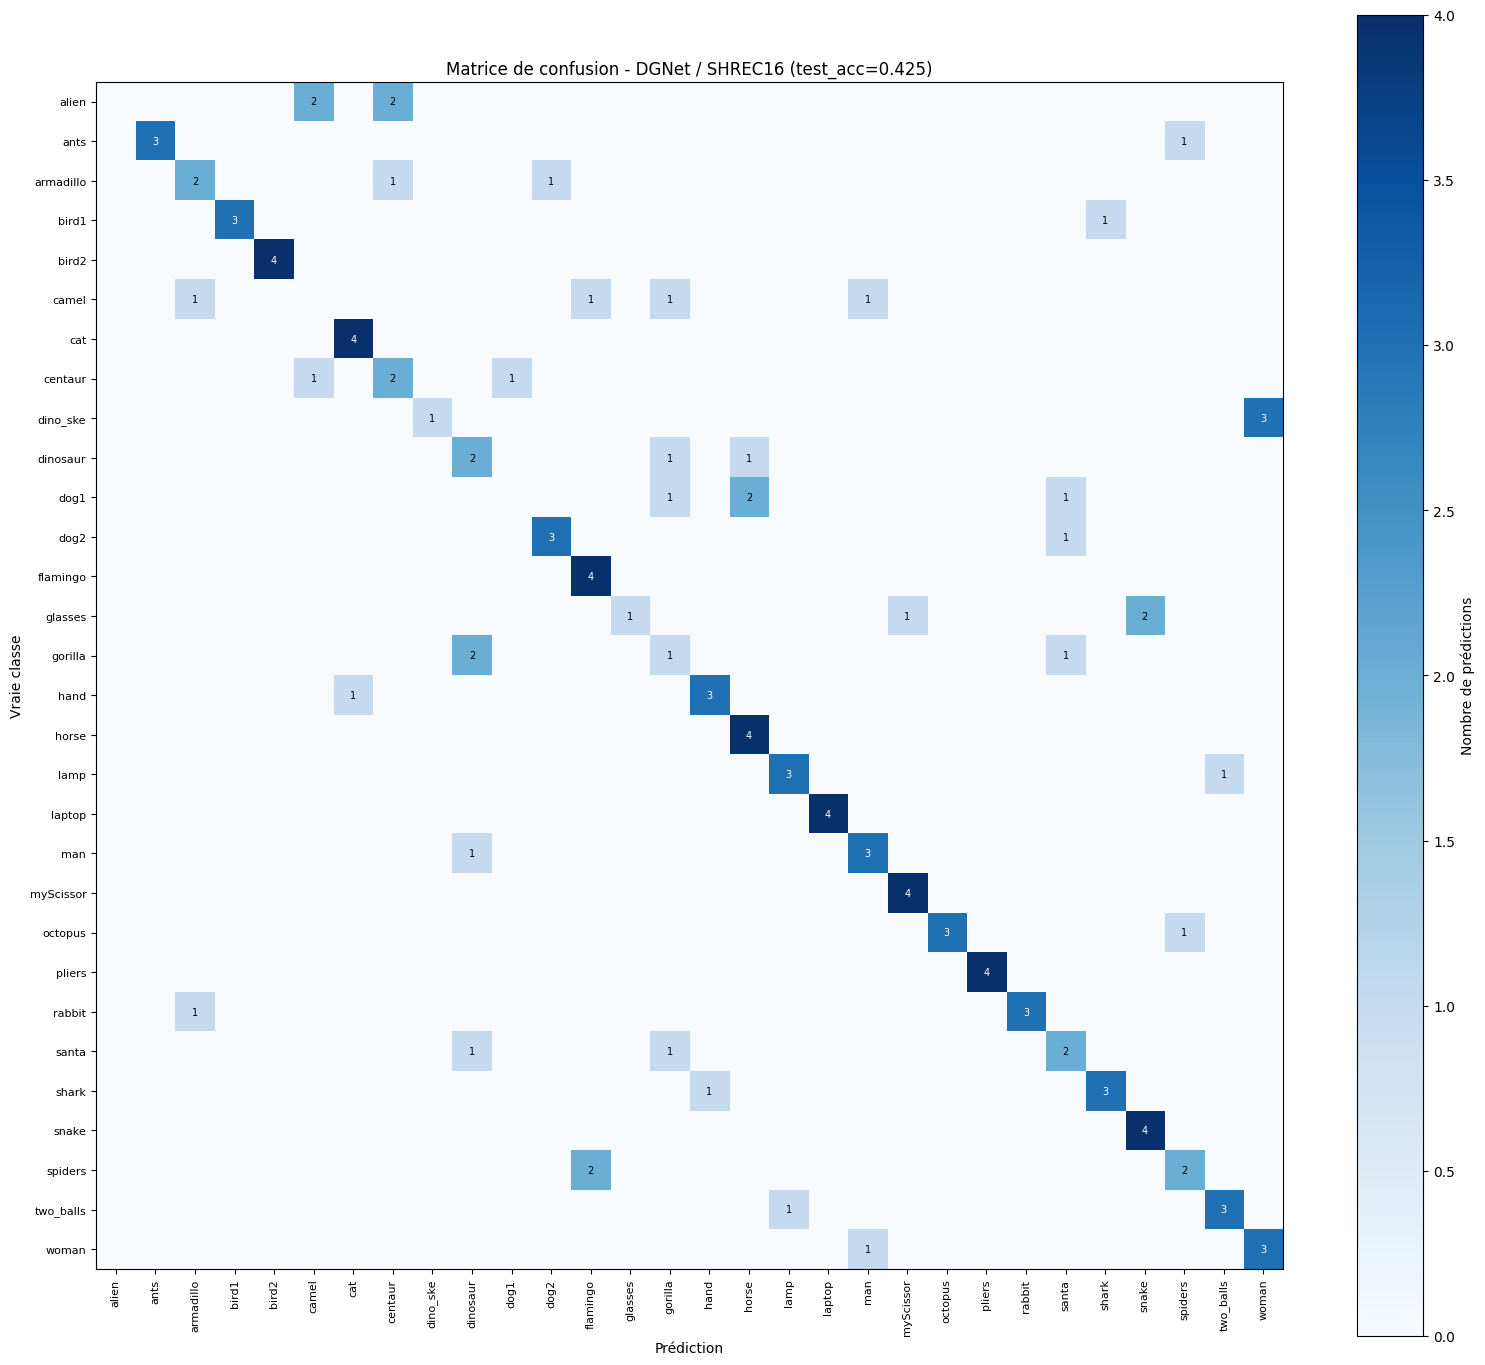

Matrice sauvegardée : /kaggle/working/shrec16_training_output/confusion_matrix_shrec16.png

=== Métriques de classification ===
Accuracy              : 0.6500
Precision (macro)     : 0.6531
Recall (macro)        : 0.6500
F1-score (macro)      : 0.6263
Precision (weighted)  : 0.6531
Recall (weighted)     : 0.6500
F1-score (weighted)   : 0.6263

              precision    recall  f1-score   support

       alien       0.00      0.00      0.00         4
        ants       1.00      0.75      0.86         4
   armadillo       0.50      0.50      0.50         4
       bird1       1.00      0.75      0.86         4
       bird2       1.00      1.00      1.00         4
       camel       0.00      0.00      0.00         4
         cat       0.80      1.00      0.89         4
     centaur       0.40      0.50      0.44         4
    dino_ske       1.00      0.25      0.40         4
    dinosaur       0.33      0.50      0.40         4
        dog1       0.00      0.00      0.00         4
     

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_recall_fscore_support,
)

CLASS_NAMES = [
    "alien", "ants", "armadillo", "bird1", "bird2", "camel", "cat", "centaur",
    "dino_ske", "dinosaur", "dog1", "dog2", "flamingo", "glasses", "gorilla",
    "hand", "horse", "lamp", "laptop", "man", "myScissor", "octopus", "pliers",
    "rabbit", "santa", "shark", "snake", "spiders", "two_balls", "woman",
]

predictions_data = np.load(SHREC16_TRAINING_OUTPUT_DIR / "final_predictions.npz")
y_pred = predictions_data["predictions"]
y_true = predictions_data["labels"]

# --- Matrice de confusion ---
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vraie classe")
ax.set_title("Matrice de confusion - DGNet / SHREC16 (test_acc=0.425)")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if cm[i, j] > 0:
            text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=text_color, fontsize=7)

fig.colorbar(im, ax=ax, label="Nombre de prédictions")
plt.tight_layout()
cm_path = SHREC16_TRAINING_OUTPUT_DIR / "confusion_matrix_shrec16.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print("Matrice sauvegardée :", cm_path)

# --- Métriques globales ---
accuracy = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print("\n=== Métriques de classification ===")
print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision (macro)     : {precision_macro:.4f}")
print(f"Recall (macro)        : {recall_macro:.4f}")
print(f"F1-score (macro)      : {f1_macro:.4f}")
print(f"Precision (weighted)  : {precision_weighted:.4f}")
print(f"Recall (weighted)     : {recall_weighted:.4f}")
print(f"F1-score (weighted)   : {f1_weighted:.4f}")

# --- Rapport détaillé par classe ---
print("\n" + classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# --- Les confusions les plus fréquentes (hors diagonale) ---
print("\n=== Top 15 confusions les plus fréquentes ===")
confusions = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i, j] > 0:
            confusions.append((cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
confusions.sort(reverse=True)
for count, true_class, pred_class in confusions[:15]:
    print(f"  {true_class:<12} confondu avec {pred_class:<12} : {count} fois")

In [33]:
shrec16_computational_metrics_script_path = WORKING_ROOT / "run_shrec16_computational_metrics.py"

shrec16_computational_metrics_script_source = '''
import sys
import time
import json
import subprocess
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.mesh_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)
    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.
    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.
    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)
    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats
    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute

CLASS_NAMES = [
    "alien", "ants", "armadillo", "bird1", "bird2", "camel", "cat", "centaur",
    "dino_ske", "dinosaur", "dog1", "dog2", "flamingo", "glasses", "gorilla",
    "hand", "horse", "lamp", "laptop", "man", "myScissor", "octopus", "pliers",
    "rabbit", "santa", "shark", "snake", "spiders", "two_balls", "woman",
]

WARMUP_ITERATIONS = 10

jt.flags.use_cuda = 1 if jt.has_cuda else 0

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES))
model.load(str(OUTPUT_DIR / "checkpoints" / "best_model.pkl"))
model.eval()

num_params = sum(p.numel() for p in model.parameters())

test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=1, shuffle=False, num_workers=0,
)

all_inference_times = []
with jt.no_grad():
    for mesh_tensor, labels in test_dataset:
        jt.sync_all(True)
        started_at = time.perf_counter()
        logits = model(mesh_tensor)
        jt.sync_all(True)
        all_inference_times.append(time.perf_counter() - started_at)

all_inference_times = np.array(all_inference_times)
steady_times = all_inference_times[WARMUP_ITERATIONS:]

avg_inference_time_steady = float(steady_times.mean())
std_inference_time_steady = float(steady_times.std())

try:
    nvidia_smi_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
        capture_output=True, text=True, check=True,
    )
    used_mb, total_mb = nvidia_smi_result.stdout.strip().split(",")
    gpu_memory_used_mb = float(used_mb.strip())
    gpu_memory_total_mb = float(total_mb.strip())
except Exception:
    gpu_memory_used_mb = None
    gpu_memory_total_mb = None

try:
    gpu_name_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True, text=True, check=True,
    )
    gpu_name = gpu_name_result.stdout.strip()
except Exception:
    gpu_name = "inconnu"

computational_metrics = {
    "num_parameters": int(num_params),
    "avg_inference_time_ms_steady_state": avg_inference_time_steady * 1000,
    "std_inference_time_ms_steady_state": std_inference_time_steady * 1000,
    "gpu_memory_used_mb": gpu_memory_used_mb,
    "gpu_memory_total_mb": gpu_memory_total_mb,
    "gpu_name": gpu_name,
    "test_set_size": len(test_dataset.files),
}

with open(OUTPUT_DIR / "computational_metrics.json", "w", encoding="utf-8") as f:
    json.dump(computational_metrics, f, indent=2)

print("Nombre de parametres :", num_params)
print(f"Temps d'inference (regime stable): {avg_inference_time_steady*1000:.2f} ms")
print("GPU :", gpu_name, "-", gpu_memory_used_mb, "/", gpu_memory_total_mb, "Mo")
print("\\n✅ Metriques calculatoires sauvegardees.")
'''

shrec16_computational_metrics_script_path.write_text(shrec16_computational_metrics_script_source, encoding="utf-8")
print("Script écrit :", shrec16_computational_metrics_script_path)

Script écrit : /kaggle/working/run_shrec16_computational_metrics.py


In [34]:
process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(shrec16_computational_metrics_script_path), str(PROJECT_ROOT), str(SHREC16_OUTPUT_ROOT), str(SHREC16_TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0914 11:35:52.157458 36 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0914 11:35:52.160728 36 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0914 11:35:52.160825 36 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x02/IntelRXeonRCPUx5a/9ee7/default
[i 0914 11:35:52.164638 36 compiler.py:900] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc
[i 0914 11:35:52.168541 36 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0914 11:35:52.306170 36 compiler.py:1012] cuda key:cu12.8.93_sm_60
[i 0914 11:35:52.867177 36 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.
[i 0914 11:35:53.028870 36 jit_compiler.cc:28] Load cc_path: /usr/bin/g++
[i 0914 11:35:53.028915 36 jit_compiler.cc:31] Load nvcc_path: /usr/local/cuda/bin/nvcc
[i 0914 11:35:53.134972 36 init.cc:63] Found cuda archs: [60,]
[i 0914 11:35:53.147877 36 __init__.py:412] Found mpicc(4.1.2) at /us

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

classification_metrics = {
    "accuracy": float(accuracy),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
}
with open(SHREC16_TRAINING_OUTPUT_DIR / "classification_metrics.json", "w", encoding="utf-8") as f:
    json.dump(classification_metrics, f, indent=2)

with open(SHREC16_TRAINING_OUTPUT_DIR / "training_info.json") as f:
    training_info = json.load(f)
with open(SHREC16_TRAINING_OUTPUT_DIR / "computational_metrics.json") as f:
    computational_metrics = json.load(f)

zero_score_classes = [
    CLASS_NAMES[i] for i in range(len(CLASS_NAMES))
    if f1_score(y_true == i, y_pred == i, zero_division=0) == 0
]

report_content = f"""# Rapport d'expérience — DGNet sur SHREC16 Original

## 1. Architecture et implémentation

| Champ | Valeur |
|---|---|
| Architecture | DGNet |
| Dépôt officiel | https://github.com/li-xl/DGNet |
| Dataset | SHREC16 Original (format .obj, dépôt MeshCNN) |
| Nombre de classes | 30 |
| Modifications | Identiques à celles documentées pour ModelNet10 (§5.1) : tête de
classification, radius=[None,0.2,0.4,0.8], SpatialConv.execute patché (matmul),
normalisation des sommets, environnement Python 3.10 |

## 2. Particularité du prétraitement

Contrairement à ModelNet10, les maillages SHREC16 sont déjà uniformément simplifiés
à exactement 500 faces par le dataset source — **aucune étape de simplification
Open3D n'a été nécessaire**. La pyramide DGNet à 6 niveaux a été construite
directement, avec un pilote réussi à 30/30 classes puis un prétraitement complet
des 600 maillages (480 train / 120 test) réussi à 100% en 1,5 minute.

## 3. Configuration d'entraînement

| Paramètre | Valeur |
|---|---|
| Nombre d'epochs | {training_info['num_epochs']} |
| Batch size | {training_info['batch_size']} |
| Optimiseur | {training_info['optimizer']} |
| Learning rate initial | {training_info['learning_rate']} |
| Scheduler | {training_info['lr_scheduler']} |
| Weight decay | {training_info['weight_decay']} |
| Loss function | {training_info['loss_function']} |
| Hardware | {computational_metrics['gpu_name']} |
| Seed aléatoire | {training_info['random_seed']} |
| Taille train / test | {training_info['train_size']} / {training_info['test_size']} |
| Durée totale d'entraînement | {training_info['total_training_time_seconds']/60:.1f} min |
| Meilleure epoch | {training_info['best_epoch']} |

## 4. Résultats

| Métrique | Valeur |
|---|---|
| Accuracy | {classification_metrics['accuracy']:.4f} |
| Precision (macro) | {classification_metrics['precision_macro']:.4f} |
| Recall (macro) | {classification_metrics['recall_macro']:.4f} |
| F1-score (macro) | {classification_metrics['f1_macro']:.4f} |
| Nombre de paramètres | {computational_metrics['num_parameters']:,} |
| Temps d'inférence (régime stable) | {computational_metrics['avg_inference_time_ms_steady_state']:.2f} ms |
| Mémoire GPU utilisée | {computational_metrics['gpu_memory_used_mb']:.0f} / {computational_metrics['gpu_memory_total_mb']:.0f} Mo |

## 5. Analyse

L'accuracy obtenue ({classification_metrics['accuracy']:.1%}) est nettement inférieure
à celle obtenue sur ModelNet10 (70,5%). Le train_acc final reste également bas
(~28-30%), ce qui indique un **sous-apprentissage** plutôt qu'un surapprentissage :
le modèle peine à apprendre même sur l'ensemble d'entraînement.

Cause principale identifiée : **très peu d'exemples par classe** (16 maillages
d'entraînement et 4 de test par classe, contre plusieurs centaines pour ModelNet10).

L'analyse de la matrice de confusion montre que les erreurs ne sont pas aléatoires :
le modèle confond principalement des classes aux silhouettes géométriquement proches
(`man`, `woman`, `gorilla`, `centaur` sont fréquemment prédits comme `dino_ske`,
toutes des formes bipèdes/articulées allongées). Ceci suggère que le modèle apprend
des caractéristiques de forme globalement pertinentes, mais ne dispose pas
d'assez d'exemples pour affiner la discrimination entre classes similaires.

**{len(zero_score_classes)} classes sur 30 ont un F1-score de 0** (jamais prédites
correctement) : {', '.join(zero_score_classes)}.

Ce résultat constitue une **baseline légitime** pour la comparaison avec la version
augmentée du dataset (cahier des charges §2, "Analyzing the effect of augmentation"),
puisque l'augmentation de données est précisément la technique attendue pour
compenser ce manque d'exemples par classe.

## 6. Visualisations

- Matrice de confusion : `confusion_matrix_shrec16.png`
- Rapport de classification détaillé par classe disponible dans les logs d'exécution

## 7. Reproductibilité

- Seed aléatoire : {training_info['random_seed']}
- Checkpoints : `checkpoints/best_model.pkl`, `checkpoints/final_model.pkl`
- Historique complet : `training_history.csv`
- Prédictions finales (test) : `final_predictions.npz`
"""

report_path = SHREC16_TRAINING_OUTPUT_DIR / "RAPPORT_DGNet_SHREC16.md"
report_path.write_text(report_content, encoding="utf-8")
print("Rapport écrit :", report_path)

Rapport écrit : /kaggle/working/shrec16_training_output/RAPPORT_DGNet_SHREC16.md
